In [52]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
code = "20_2_6"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X"
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 20_2_6
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Chosen CNOT gates: [(1, 2), (2, 19), (8, 12), (3, 12), (9, 6), (16, 0), (7, 4), (10, 0), (3, 0), (3, 6), (7, 6), (7, 1), (18, 1), (16, 6), (5, 4), (14, 19), (14, 17), (10, 14), (13, 2), (13, 7), (12, 2), (14, 13), (2, 19), (4, 12), (1, 14), (0, 4), (2, 1), (1, 0)]
Computing initial single faults...

Running verification stabilizers search for t=3 layers (top_n=50, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 60.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 74.0
  [Layer 3] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 74.0
  [Chosen Stabilizers] (Violations: 2)
    -> Layer 1: ['00100010000000110000', '00101000000101010010', '01001000001001000000', '10000100000010000001']
    -> Layer 2: ['0000100100

Num CX: 153


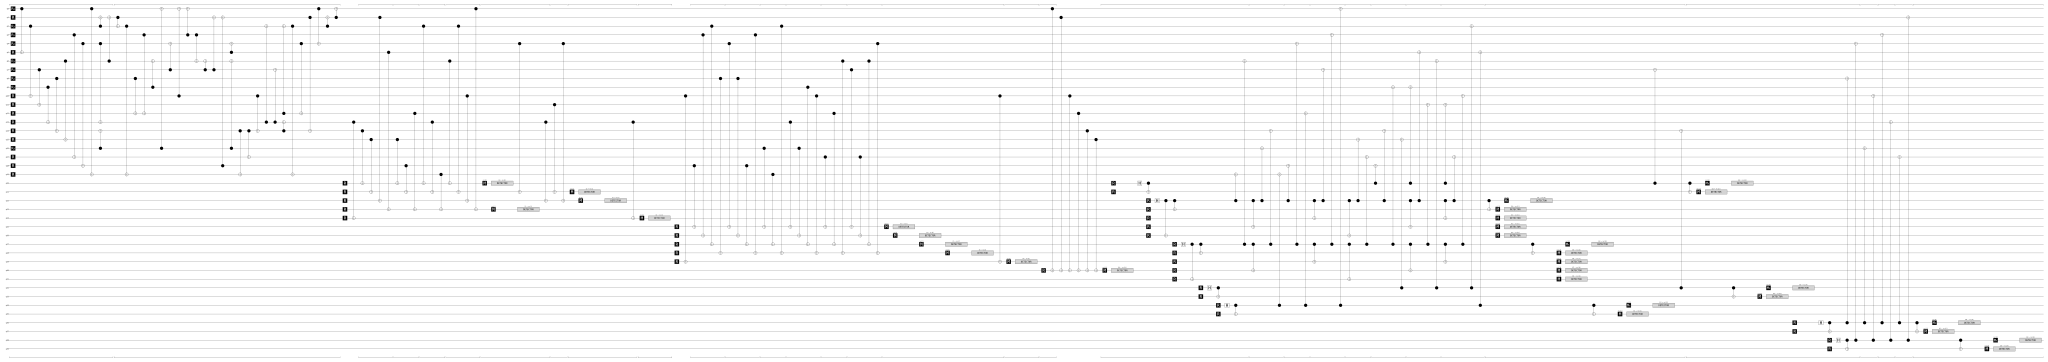

In [59]:
print(f"Num CX: {count_operations(final_circ)[0]}")

final_circ.diagram('timeline-svg')

In [60]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]]


In [61]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=6, t=3)...
    [FAIL] Catastrophic cascade found!
    W(E_init)=3 faults bypassed flags to require only W(E_data)=2 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


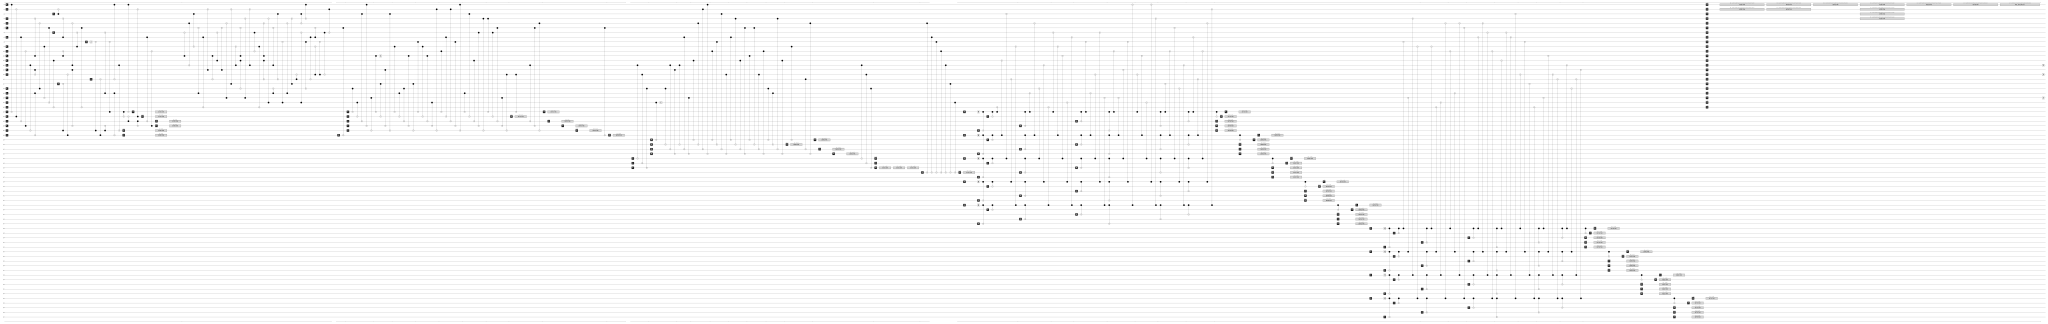

In [57]:
res_exhaustive.diagram("timeline-svg")

In [32]:
if True:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

In [66]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[26];
creg c[9];
h q[25];
h q[20];
h q[21];
h q[17];
h q[0];
h q[3];
h q[5];
h q[9];
h q[10];
h q[11];
h q[12];
h q[13];
cx q[17], q[23];
cx q[20], q[18];
cx q[21], q[19];
cx q[5], q[7];
cx q[12], q[15];
cx q[11], q[14];
cx q[10], q[8];
cx q[0], q[2];
cx q[12], q[6];
cx q[3], q[7];
cx q[15], q[4];
cx q[10], q[16];
cx q[9], q[11];
cx q[16], q[24];
cx q[12], q[14];
cx q[13], q[7];
cx q[8], q[15];
cx q[6], q[1];
cx q[0], q[3];
cx q[4], q[2];
cx q[9], q[10];
cx q[25], q[13];
cx q[25], q[3];
cx q[12], q[22];
cx q[4], q[24];
cx q[15], q[18];
cx q[2], q[19];
cx q[17], q[0];
cx q[11], q[8];
cx q[14], q[16];
cx q[7], q[6];
cx q[1], q[22];
cx q[5], q[4];
cx q[13], q[12];
cx q[15], q[24];
cx q[14], q[18];
cx q[17], q[10];
cx q[3], q[1];
cx q[5], q[19];
cx q[10], q[18];
measure q[22] -> c[0];
measure q[24] -> c[1];
cx q[13], q[19];
cx q[17], q[1];
cx q[1], q[19];
cx q[17], q[11];
cx q[11], q[18];
cx q[17], q[4];
cx q[20], q[18];
cx q[17], q[16];
measure q[18] -> c[2];
cx q[17], q[7];
h q[20];
measure q[20] -> c[3];
cx q[7], q[19];
cx q[17], q[12];
cx q[17], q[23];
cx q[21], q[19];
h q[17];
measure q[17] -> c[4];
measure q[19] -> c[5];
h q[21];
measure q[21] -> c[6];
measure q[23] -> c[7];
h q[25];
measure q[25] -> c[8];
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

print(bens_circ)

Num CX: 53
Total instructions: 62
Depth: 16
H 25 20 21 17 0 3 5 9 10 11 12 13
CX 17 23 20 18 21 19 5 7 12 15 11 14 10 8 0 2 12 6 3 7 15 4 10 16 9 11 16 24 12 14 13 7 8 15 6 1 0 3 4 2 9 10 25 13 25 3 12 22 4 24 15 18 2 19 17 0 11 8 14 16 7 6 1 22 5 4 13 12 15 24 14 18 17 10 3 1 5 19 10 18
M 22 24
CX 13 19 17 1 1 19 17 11 11 18 17 4 20 18 17 16
M 18
CX 17 7
H 20
M 20
CX 7 19 17 12 17 23 21 19
H 17
M 17 19
H 21
M 21 23
H 25
M 25
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
DETECTOR rec[-5]
DETECTOR rec[-6]
DETECTOR rec[-7]
DETECTOR rec[-8]
DETECTOR rec[-9]


In [51]:
x_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]
])

z_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
])

z_logs_17_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ z_stabs_17_1_5.T % 2)
print(meas_samples @ z_logs_17_1_5.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[0 0 0 0 0 0 0 0 0 0]


In [79]:
print("\nRunning Fast DEM/SAT FT Verification...")
# res_exhaustive = verify_ftsp(
#     prep_circ=bens_circ,
#     H_primary=z_stabs_17_1_5, L_primary=np.atleast_2d(z_logs_17_1_5),
#     H_conjugate=z_stabs_17_1_5, L_conjugate=np.atleast_2d(z_logs_17_1_5),
#     d=5, t=2,
#     primary_basis="Z", conjugate_basis="X",
#     verbose=True
# )
res_exhaustive = stim.Circuit("""
RX 4 5
R 7 8 9
RX 10
R 11
X 11
RX 12
R 14
RX 15 16
R 17
RX 18 19
R 20
RX 21
R 22
CX 19 3 10 20 21 14 16 22 4 8 5 9 15 7 12 17 18 11
RX 1
R 2 13
CX 22 8 4 3 5 2 15 19 1 7 12 13 18 14 20 11 16 2 22 19 1 21 10 13
RX 6
CX 6 19 16 22 20 21
M 22
CX 19 3 6 21 10 20
MX 19
M 20
CX 21 14
MX 21
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
R 0
CX 7 0 8 13 11 17 7 2 8 9 14 0 13 11 6 7 2 8 14 3
TICK
R 19 20
H 19 20
TICK
CX 19 8
TICK
CX 19 9
TICK
CX 19 12 20 1
TICK
CX 19 7 20 4
TICK
CX 19 6 20 0
TICK
CX 19 18 20 6
TICK
CX 19 11 20 16
TICK
CX 19 4 20 3
TICK
H 19
M 19
DETECTOR rec[-1]
H 20
M 20
DETECTOR rec[-1]
R 21
H 21
TICK
CX 21 3
TICK
CX 21 6
TICK
CX 21 7
TICK
CX 21 10
TICK
CX 21 11
TICK
CX 21 12
TICK
H 21
M 21
DETECTOR rec[-1]
H 4 7 12 13 14 15 16 18
R 19
H 19
R 22
CX 19 22
R 21
CX 19 21 22 18
R 20
CX 19 20 21 14 19 16 21 13 19 15 19 22 19 12
M 22
CX 19 7 19 21 19 4
M 21
CX 19 20
M 20
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 19
H 4 7 12 13 14 15 16 18
DETECTOR rec[-1]
H 4 5 9 16
R 23
H 23
R 24
CX 23 24 23 16 23 9 23 5
Z 5
CX 23 4 23 24
M 24
DETECTOR rec[-1]
MX 23
H 4 5 9 16
DETECTOR rec[-1]
H 3 5 8 11 13 16
R 25
H 25
R 28
CX 25 28
R 27
CX 25 27
R 26
CX 25 26 27 13 25 16 27 11 25 28 25 8
M 28
CX 25 5 25 27 25 3
M 27
CX 25 26
M 26
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 25
H 3 5 8 11 13 16
DETECTOR rec[-1]
H 0 6 7 14
R 29
H 29
R 30
CX 29 30 29 14 29 7 29 6 29 0 29 30
M 30
DETECTOR rec[-1]
MX 29
H 0 6 7 14
DETECTOR rec[-1]
H 5 9 11 12 18
R 31
H 31
R 33
CX 31 33
R 32
CX 31 32 33 18 33 12 31 11 31 9 31 33 31 5
M 33
CX 31 32
M 32
DETECTOR rec[-1]
DETECTOR rec[-2]
MX 31
H 5 9 11 12 18
DETECTOR rec[-1]
H 2 8 10 12 13
R 34
H 34
R 36
CX 34 36
R 35
CX 34 35 36 13 36 12 34 10 34 8 34 36 34 2
M 36
CX 34 35
M 35
DETECTOR rec[-1]
DETECTOR rec[-2]
MX 34
H 2 8 10 12 13
DETECTOR rec[-1]
M 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
DETECTOR rec[-17] rec[-14] rec[-11] rec[-10]
DETECTOR rec[-9] rec[-7] rec[-2] rec[-1]
DETECTOR rec[-9] rec[-8] rec[-6] rec[-1]
DETECTOR rec[-19] rec[-18] rec[-5] rec[-4]
DETECTOR rec[-19] rec[-18] rec[-16] rec[-15] rec[-13] rec[-3]
DETECTOR rec[-17] rec[-15] rec[-11] rec[-3]
DETECTOR rec[-18] rec[-13] rec[-12] rec[-4]
DETECTOR rec[-16] rec[-13] rec[-12] rec[-9] rec[-8] rec[-7]
DETECTOR rec[-16] rec[-15] rec[-11] rec[-10] rec[-8] rec[-6]
OBSERVABLE_INCLUDE(0) rec[-15] rec[-14] rec[-13] rec[-12] rec[-11]
TICK
X 9 10
""")
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...
Verification Result: False


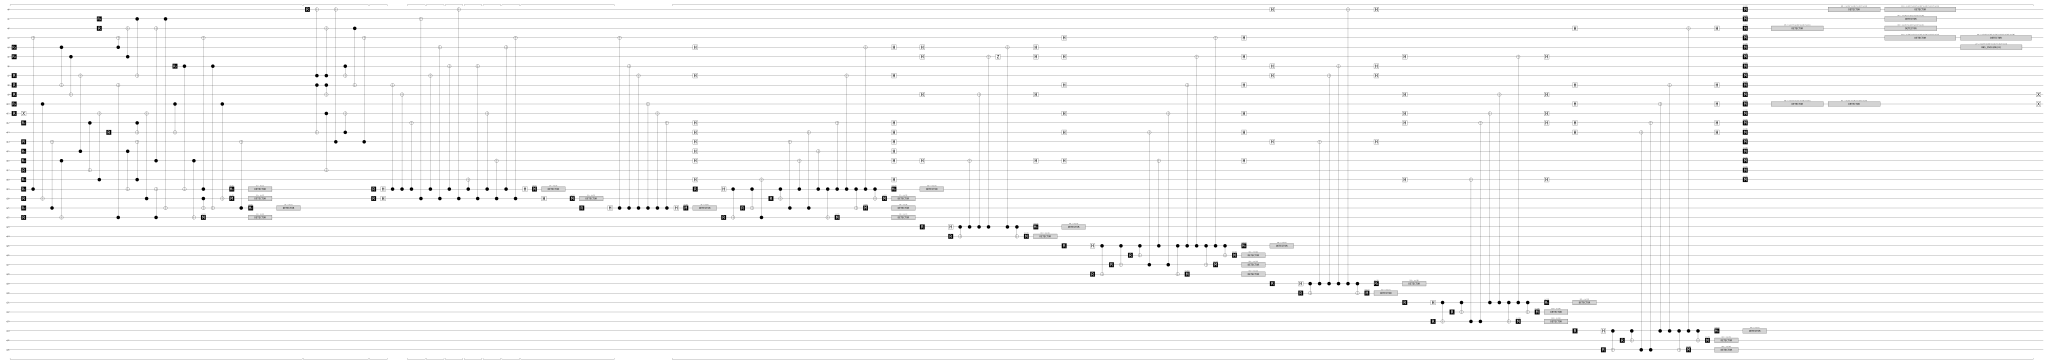

In [80]:
res_exhaustive.diagram('timeline-svg')

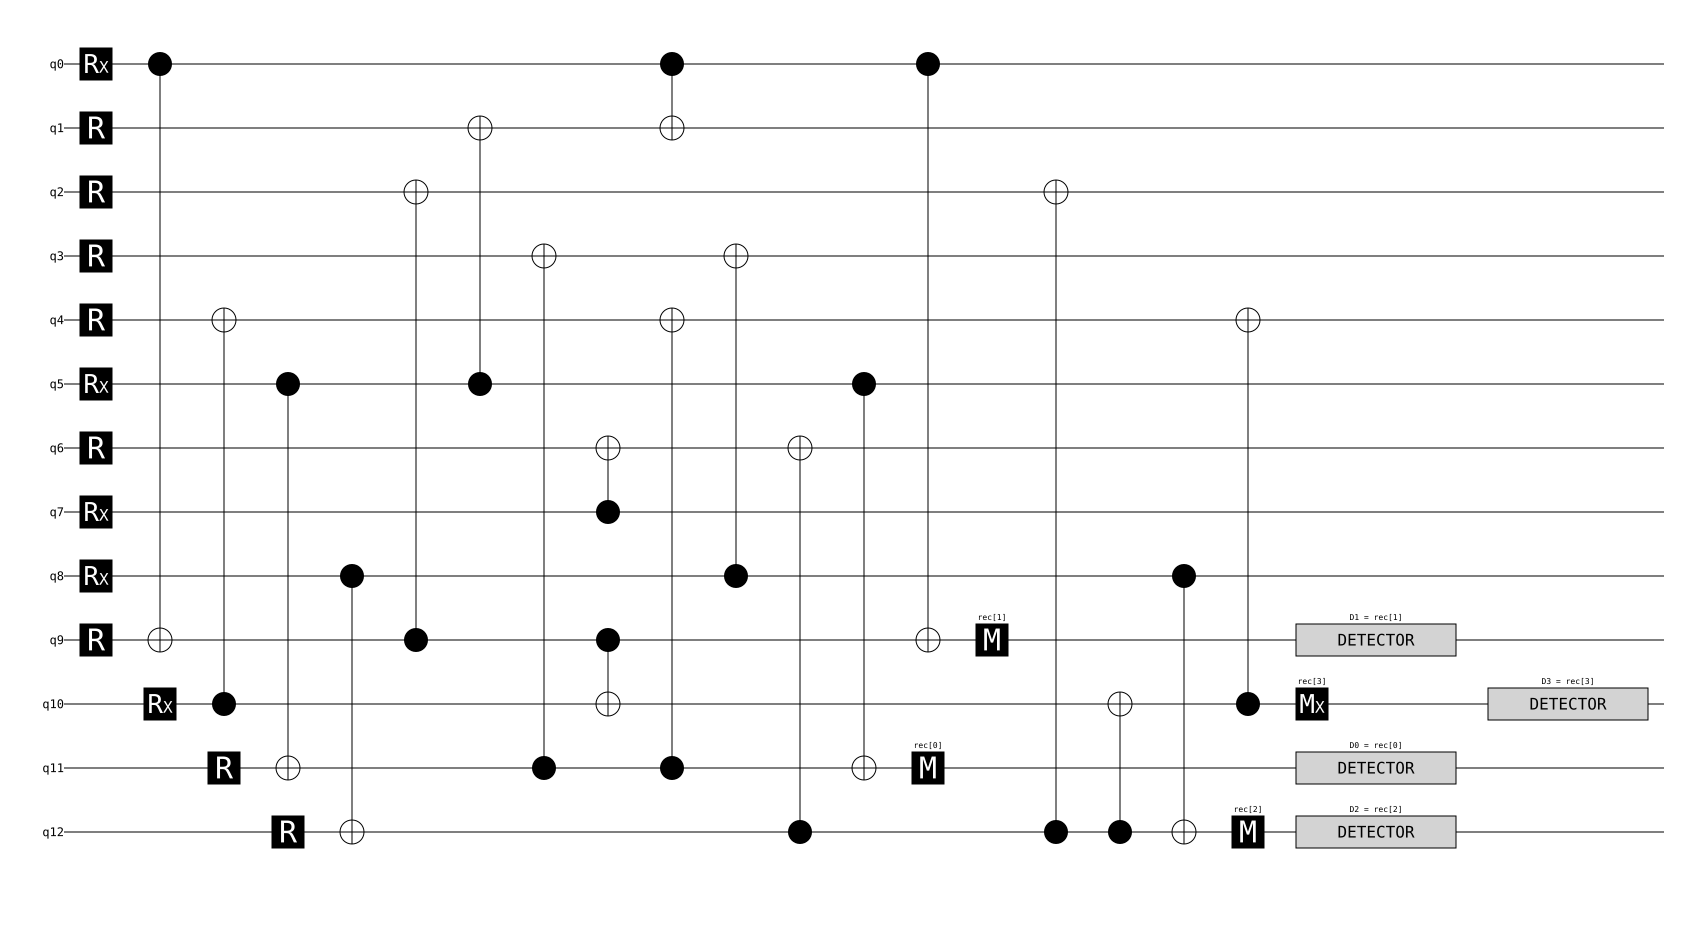

In [158]:
stabs = np.array([[0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 1, 0, 1],
       [0, 1, 0, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 0, 1, 0, 0, 0, 0]])
circ = cat_at_origin(stabs, 0)
circ.diagram('timeline-svg')

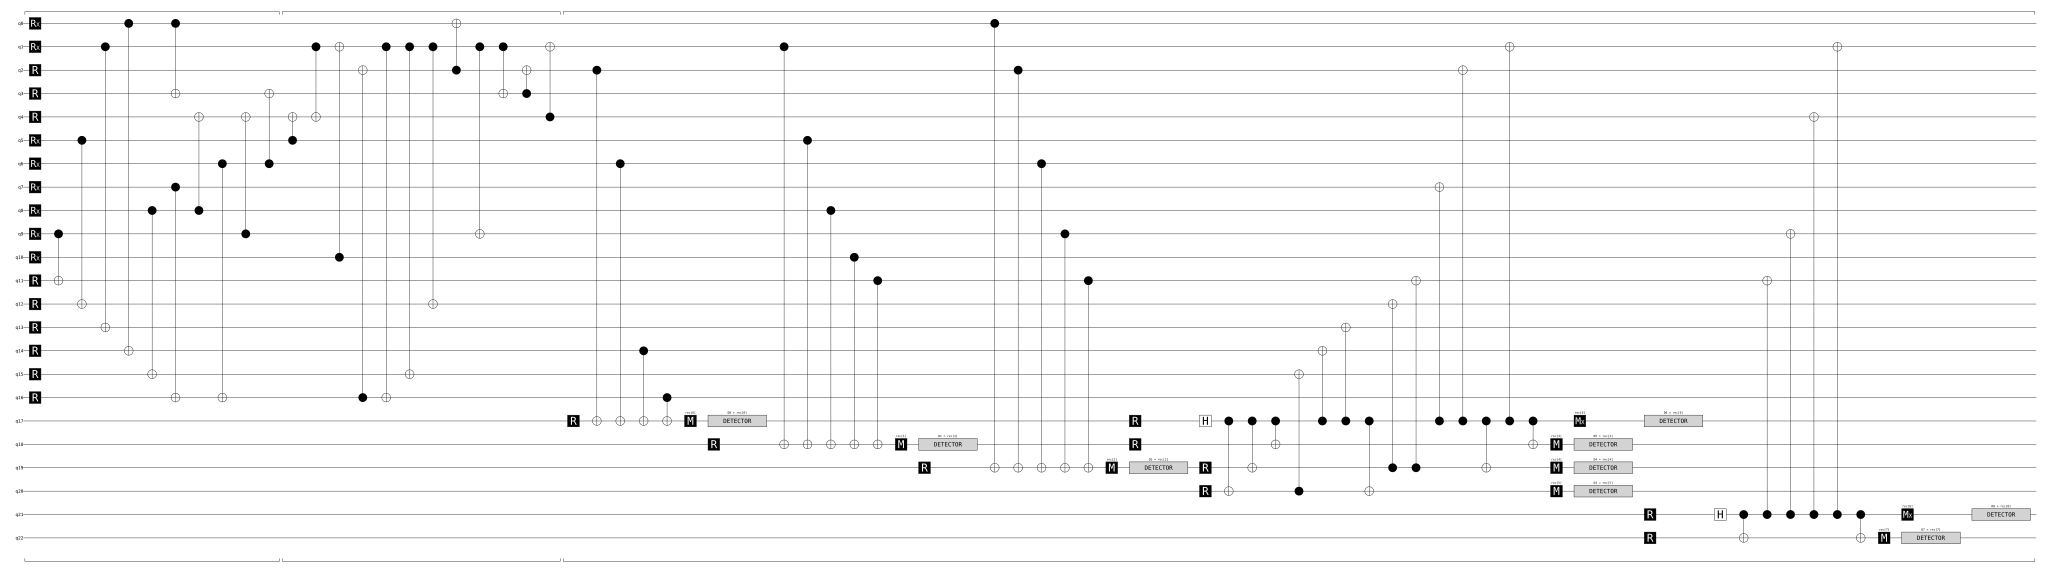

In [198]:
stim.Circuit("""
RX 0 1
R 2 3 4
RX 5 6 7 8 9 10
R 11 12 13 14 15 16
CX 9 11 5 12 1 13 0 14 8 15 7 16 0 3 8 4 6 16 9 4 6 3
TICK
CX 5 4 1 4 10 1 16 2 1 16 1 15 1 12 2 0 1 9 1 3 3 2 4 1
TICK
R 17
CX 2 17 6 17 14 17 16 17
M 17
DETECTOR rec[-1]
R 18
CX 1 18 5 18 8 18 10 18 11 18
M 18
DETECTOR rec[-1]
R 19
CX 0 19 2 19 6 19 9 19 11 19
M 19
DETECTOR rec[-1]
R 17 18 19 20
H 17
CX 17 20 17 19 17 18 20 15 17 14 17 13 17 20 19 12 19 11 17 7 17 2 17 19 17 1 17 18
M 18 19 20
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 17
DETECTOR rec[-1]
R 21 22
H 21
CX 21 22 21 11 21 9 21 4 21 1 21 22
M 22
DETECTOR rec[-1]
MX 21
DETECTOR rec[-1]
""").diagram('timeline-svg')

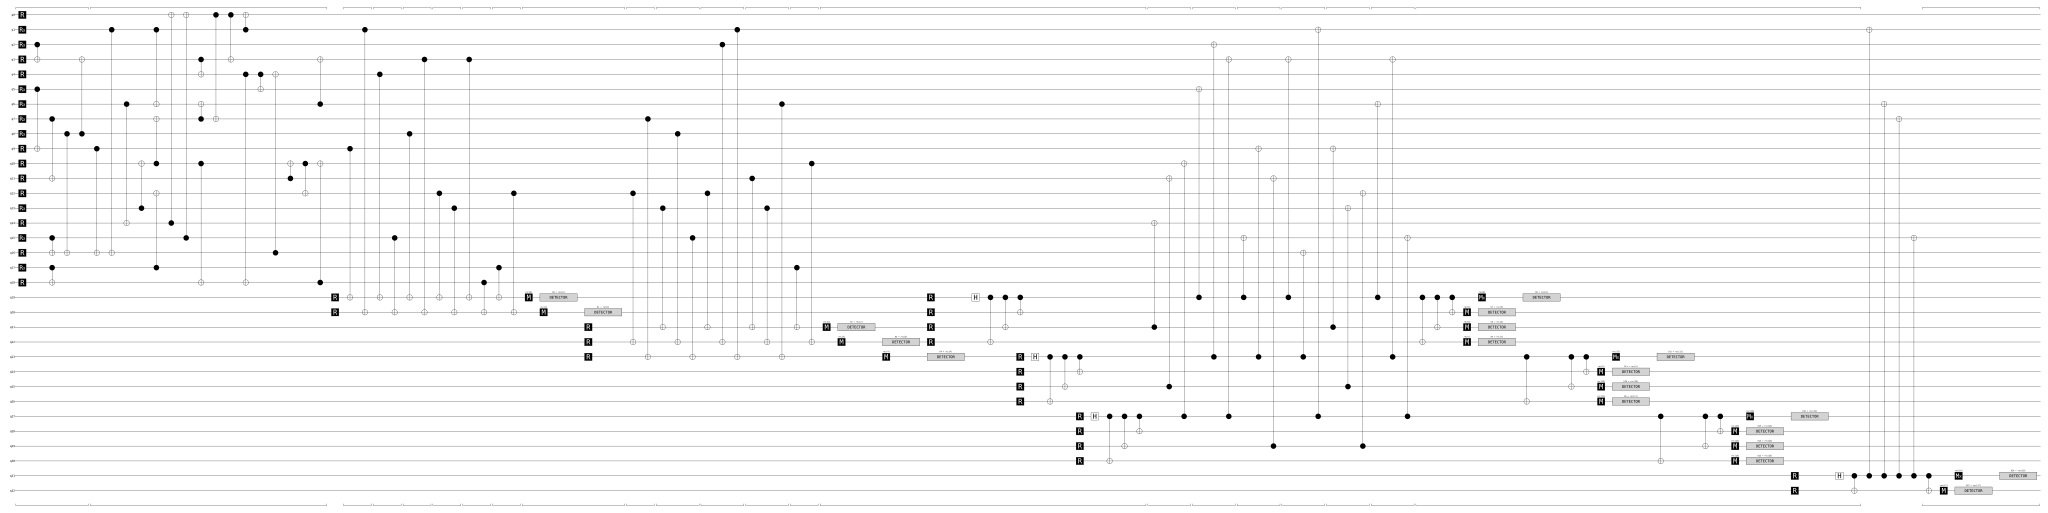

In [75]:
stim.Circuit("""
R 0
RX 1 2
R 3 4
RX 5 6 7 8
R 9 10 11 12
RX 13
R 14
RX 15
R 16
RX 17
R 18
CX 2 3 5 9 7 11 15 16 17 18 8 16 8 3
TICK
CX 9 16 1 16 6 14 13 10 17 12 10 7 1 6 14 0 15 0 10 18 7 6 3 4 0 7 0 3 1 0 4 18 4 5 16 4 11 10 10 12 18 10 6 3
TICK
R 19 20
TICK
CX 9 19 1 20
TICK
CX 4 19 15 20
TICK
CX 8 19 3 20
TICK
CX 12 19 13 20
TICK
CX 3 19 18 20
TICK
CX 17 19 12 20
TICK
M 19
DETECTOR rec[-1]
M 20
DETECTOR rec[-1]
R 21 22 23
TICK
CX 12 22 7 23
TICK
CX 13 21 8 22 15 23
TICK
CX 12 21 2 22 1 23
TICK
CX 11 21 13 22 6 23
TICK
CX 17 21 10 22
TICK
M 21
DETECTOR rec[-1]
M 22
DETECTOR rec[-1]
M 23
DETECTOR rec[-1]
R 19 20 21 22
H 19
CX 19 22 19 21 19 20
R 23 24 25 26
H 23
CX 23 26 23 25 23 24
R 27 28 29 30
H 27
CX 27 30 27 29 27 28
TICK
CX 21 14 25 11 27 10
TICK
CX 19 5 23 2 27 3
TICK
CX 19 15 23 9 29 11
TICK
CX 19 3 23 16 27 1
TICK
CX 21 9 25 13 29 12
TICK
CX 19 6 23 3 27 15
TICK
CX 19 22 19 21 19 20
M 20 21 22
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 19
DETECTOR rec[-1]
CX 23 26 23 25 23 24
M 24 25 26
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 23
DETECTOR rec[-1]
CX 27 30 27 29 27 28
M 28 29 30
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 27
DETECTOR rec[-1]
R 31 32
H 31
CX 31 32
TICK
CX 31 1
TICK
CX 31 6
TICK
CX 31 7
TICK
CX 31 15
TICK
CX 31 32
M 32
DETECTOR rec[-1]
MX 31
DETECTOR rec[-1]
""").diagram('timeline-svg')